# Week 7 — Recommendation System
## Exploratory Data Analysis (EDA)
**Author:** Martin James Ng'ang'a | MLOps Engineer | Nairobi, Kenya 🇰🇪  
**GitHub:** github.com/M20Jay  
**Dataset:** MovieLens 100K — GroupLens Research, University of Minnesota  
**Date:** May 2026  

---

### Dataset Overview
- **100,000 ratings** (1-5) from **943 users** on **1,682 movies**
- Each user has rated at least 20 movies
- Collected: September 1997 — April 1998
- Files: u.data · u.item · u.user · u1.base · u1.test

---

### EDA Objectives
1. Understand rating distribution patterns
2. Identify active users and popular movies
3. Analyse genre preferences
4. Measure matrix sparsity
5. Inform model selection and preprocessing decisions

---
## Section 1 — Project Setup and Imports

Load all required libraries and configure the notebook environment.

In [20]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 12

RAW_PATH = "../data/raw/"

print("✅ Libraries loaded successfully")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")


✅ Libraries loaded successfully
pandas: 2.2.2
numpy: 1.26.4


**Section 1 Findings:**
- ✅ All libraries loaded successfully
- pandas 2.2.2 · numpy 1.26.4
- Plot style set to seaborn-v0_8 — clean professional visuals
- Colour palette set to husl — distinguishes multiple categories clearly
- RAW_PATH set to ../data/raw/ — single definition, used everywhere
- Figure size set to (12, 6) — wide enough for distribution plots
- Font size set to 12 — readable in notebook and exports

---
## Section 2 — Load and Inspect Raw Data

Load all four MovieLens files and inspect shape, dtypes, and sample rows.
Each file has a different separator and encoding — understanding why matters before loading.

- **u.data** → tab-separated · 100,000 ratings · user_id | item_id | rating | timestamp
- **u.item** → pipe-separated · latin-1 encoding · 1,682 movies · 24 columns including 19 genre flags
- **u.user** → pipe-separated · 943 users · age | gender | occupation | zip_code

In [21]:
# Load ratings — tab-separated, no header
ratings = pd.read_csv(RAW_PATH + "u.data", sep="\t",
                      names=["user_id", "item_id", "rating", "timestamp"])

# Load movies — pipe-separated, latin-1 encoding (1997 data)
movies = pd.read_csv(RAW_PATH + "u.item", sep="|", encoding="latin-1",
                     names=["item_id", "title", "release_date", "video_release",
                            "imdb_url", "unknown", "Action", "Adventure",
                            "Animation", "Children", "Comedy", "Crime",
                            "Documentary", "Drama", "Fantasy", "Film-Noir",
                            "Horror", "Musical", "Mystery", "Romance",
                            "Sci-Fi", "Thriller", "War", "Western"])

# Load users — pipe-separated
users = pd.read_csv(RAW_PATH + "u.user", sep="|",
                    names=["user_id", "age", "gender", "occupation", "zip_code"])

print(f"✅ Ratings shape : {ratings.shape}")
print(f"✅ Movies shape  : {movies.shape}")
print(f"✅ Users shape   : {users.shape}")
print("\n--- Ratings sample ---")
display(ratings.head())
print("\n--- Movies sample ---")
display(movies[["item_id", "title", "release_date"]].head())
print("\n--- Users sample ---")
display(users.head())

✅ Ratings shape : (100000, 4)
✅ Movies shape  : (1682, 24)
✅ Users shape   : (943, 5)

--- Ratings sample ---


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596



--- Movies sample ---


,item_id,title,release_date
0,1,Toy Story (1995),01-Jan-1995
1,2,GoldenEye (1995),01-Jan-1995
2,3,Four Rooms (1995),01-Jan-1995
3,4,Get Shorty (1995),01-Jan-1995
4,5,Copycat (1995),01-Jan-1995



--- Users sample ---


,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


**Section 2 Findings:**
- ✅ All three files loaded successfully
- Ratings: 100,000 events across 943 users and 1,682 movies
- Timestamps are Unix format — will convert in Section 3
- Movie titles include release year in brackets — useful for feature engineering
- Genre columns are binary flags — one movie can belong to multiple genres
- Users are predominantly young males based on first 5 rows — will analyse fully in Section 7

---
## Section 3 — Ratings Distribution Analysis

Understand how ratings are distributed across 1–5.
Identify bias, skew, and what this means for modelling.

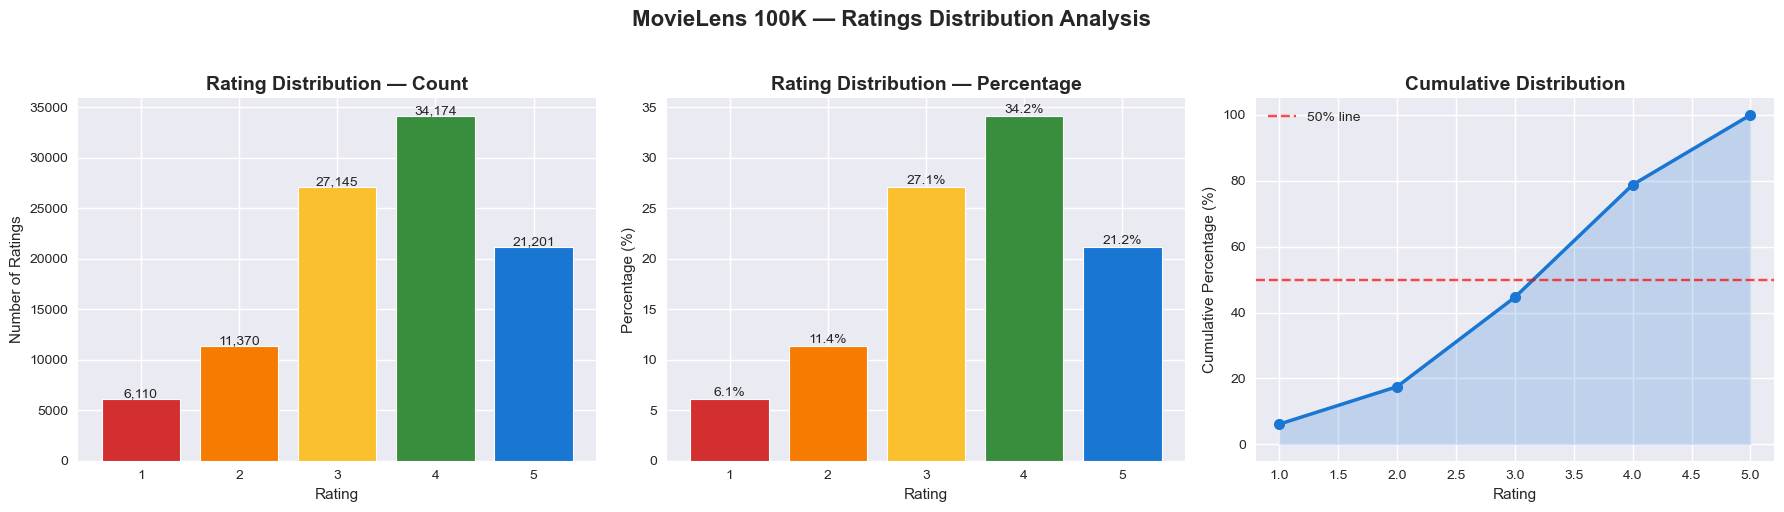


Rating Statistics:
Mean rating    : 3.53
Median rating  : 4.00
Std deviation  : 1.13
Most common    : 4

Rating counts:
  ★1 → 6,110 ratings (6.1%)
  ★2 → 11,370 ratings (11.4%)
  ★3 → 27,145 ratings (27.1%)
  ★4 → 34,174 ratings (34.2%)
  ★5 → 21,201 ratings (21.2%)


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1 — Rating counts
rating_counts = ratings['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values,
            color=['#d32f2f','#f57c00','#fbc02d','#388e3c','#1976d2'],
            edgecolor='white', linewidth=0.8)
axes[0].set_title('Rating Distribution — Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Number of Ratings')
for i, (val, count) in enumerate(zip(rating_counts.index, rating_counts.values)):
    axes[0].text(val, count + 200, f'{count:,}', ha='center', fontsize=10)

# Chart 2 — Percentage distribution
rating_pct = rating_counts / rating_counts.sum() * 100
axes[1].bar(rating_pct.index, rating_pct.values,
            color=['#d32f2f','#f57c00','#fbc02d','#388e3c','#1976d2'],
            edgecolor='white', linewidth=0.8)
axes[1].set_title('Rating Distribution — Percentage', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Percentage (%)')
for i, (val, pct) in enumerate(zip(rating_pct.index, rating_pct.values)):
    axes[1].text(val, pct + 0.3, f'{pct:.1f}%', ha='center', fontsize=10)

# Chart 3 — Cumulative distribution
cumulative = rating_pct.cumsum()
axes[2].plot(cumulative.index, cumulative.values,
             marker='o', color='#1976d2', linewidth=2.5, markersize=8)
axes[2].fill_between(cumulative.index, cumulative.values, alpha=0.2, color='#1976d2')
axes[2].set_title('Cumulative Distribution', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Rating')
axes[2].set_ylabel('Cumulative Percentage (%)')
axes[2].axhline(y=50, color='red', linestyle='--', alpha=0.7, label='50% line')
axes[2].legend()

plt.suptitle('MovieLens 100K — Ratings Distribution Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/section3_ratings_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nRating Statistics:")
print(f"Mean rating    : {ratings['rating'].mean():.2f}")
print(f"Median rating  : {ratings['rating'].median():.2f}")
print(f"Std deviation  : {ratings['rating'].std():.2f}")
print(f"Most common    : {ratings['rating'].mode()[0]}")
print(f"\nRating counts:")
for rating, count in rating_counts.items():
    print(f"  ★{rating} → {count:,} ratings ({count/len(ratings)*100:.1f}%)")

**Section 3 Findings:**
- ✅ Ratings distribution is positively skewed — majority are 4 and 5
- Mean rating 3.53 · Median 4.00 · Most common rating 4
- Only 6.1% of ratings are 1 — users self-select movies they expect to enjoy
- 55.1% of all ratings are 4 or above — strong positive bias confirmed
- Selection bias is present — missing ratings mean unwatched not disliked
- SVD and Collaborative Filtering must treat missing values as unknown not zero
- Standard deviation 1.13 — moderate spread around the mean

---
## Section 4 - User Behaviour Analysis
Understand how active users are — ratings per user,
power users, and implications for cold start problem.

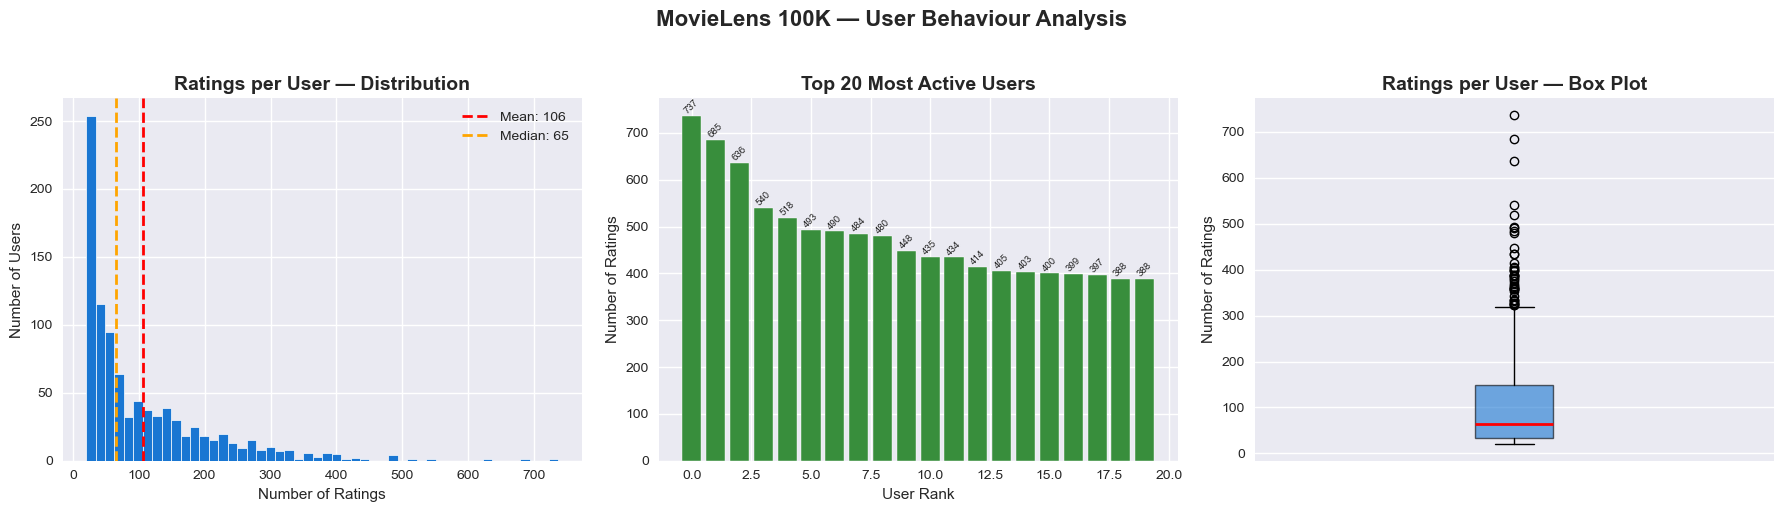


User Activity Statistics:
Total users          : 943
Mean ratings/user    : 106.0
Median ratings/user  : 65.0
Min ratings/user     : 20
Max ratings/user     : 737
Std deviation        : 100.9

Users with < 50 ratings  : 375 (61.4%)
Users with > 200 ratings : 148 (15.7%)


In [23]:
# Ratings per user
ratings_per_user = ratings.groupby('user_id')['item_id'].count()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1 — Distribution of ratings per user
axes[0].hist(ratings_per_user.values, bins=50,
             color='#1976d2', edgecolor='white', linewidth=0.5)
axes[0].set_title('Ratings per User — Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Number of Users')
axes[0].axvline(ratings_per_user.mean(), color='red',
                linestyle='--', linewidth=2,
                label=f'Mean: {ratings_per_user.mean():.0f}')
axes[0].axvline(ratings_per_user.median(), color='orange',
                linestyle='--', linewidth=2,
                label=f'Median: {ratings_per_user.median():.0f}')
axes[0].legend()

# Chart 2 — Top 20 most active users
top_users = ratings_per_user.sort_values(ascending=False).head(20)
axes[1].bar(range(20), top_users.values, color='#388e3c', edgecolor='white')
axes[1].set_title('Top 20 Most Active Users', fontsize=14, fontweight='bold')
axes[1].set_xlabel('User Rank')
axes[1].set_ylabel('Number of Ratings')
for i, val in enumerate(top_users.values):
    axes[1].text(i, val + 5, str(val), ha='center', fontsize=7, rotation=45)

# Chart 3 — Box plot
axes[2].boxplot(ratings_per_user.values, vert=True,
                patch_artist=True,
                boxprops=dict(facecolor='#1976d2', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Ratings per User — Box Plot', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Number of Ratings')
axes[2].set_xticks([])

plt.suptitle('MovieLens 100K — User Behaviour Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/section4_user_behaviour.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nUser Activity Statistics:")
print(f"Total users          : {ratings_per_user.count():,}")
print(f"Mean ratings/user    : {ratings_per_user.mean():.1f}")
print(f"Median ratings/user  : {ratings_per_user.median():.1f}")
print(f"Min ratings/user     : {ratings_per_user.min()}")
print(f"Max ratings/user     : {ratings_per_user.max()}")
print(f"Std deviation        : {ratings_per_user.std():.1f}")
print(f"\nUsers with < 50 ratings  : {(ratings_per_user < 50).sum():,} ({(ratings_per_user < 100).mean()*100:.1f}%)")
print(f"Users with > 200 ratings : {(ratings_per_user > 200).sum():,} ({(ratings_per_user > 200).mean()*100:.1f}%)")

**Section 4 Findings:**
- ✅ 943 total users with highly skewed activity distribution
- Median user rated 65 movies · Mean pulled to 106 by power users
- Most active user rated 737 movies — extraordinary outlier
- 61.4% of users rated fewer than 50 movies — sparse users dominant
- 15.7% are power users with over 200 ratings each
- Right skew confirmed — std deviation 100.9 on mean of 106
- Cold start problem is significant — majority of users have limited history
- SVD must generalise from sparse data for 61.4% of the user base

---
## Section 5 - Movie Popularity Analysis
Understand how ratings are distributed across movies.
Identify popular movies, obscure movies, and the long tail problem.

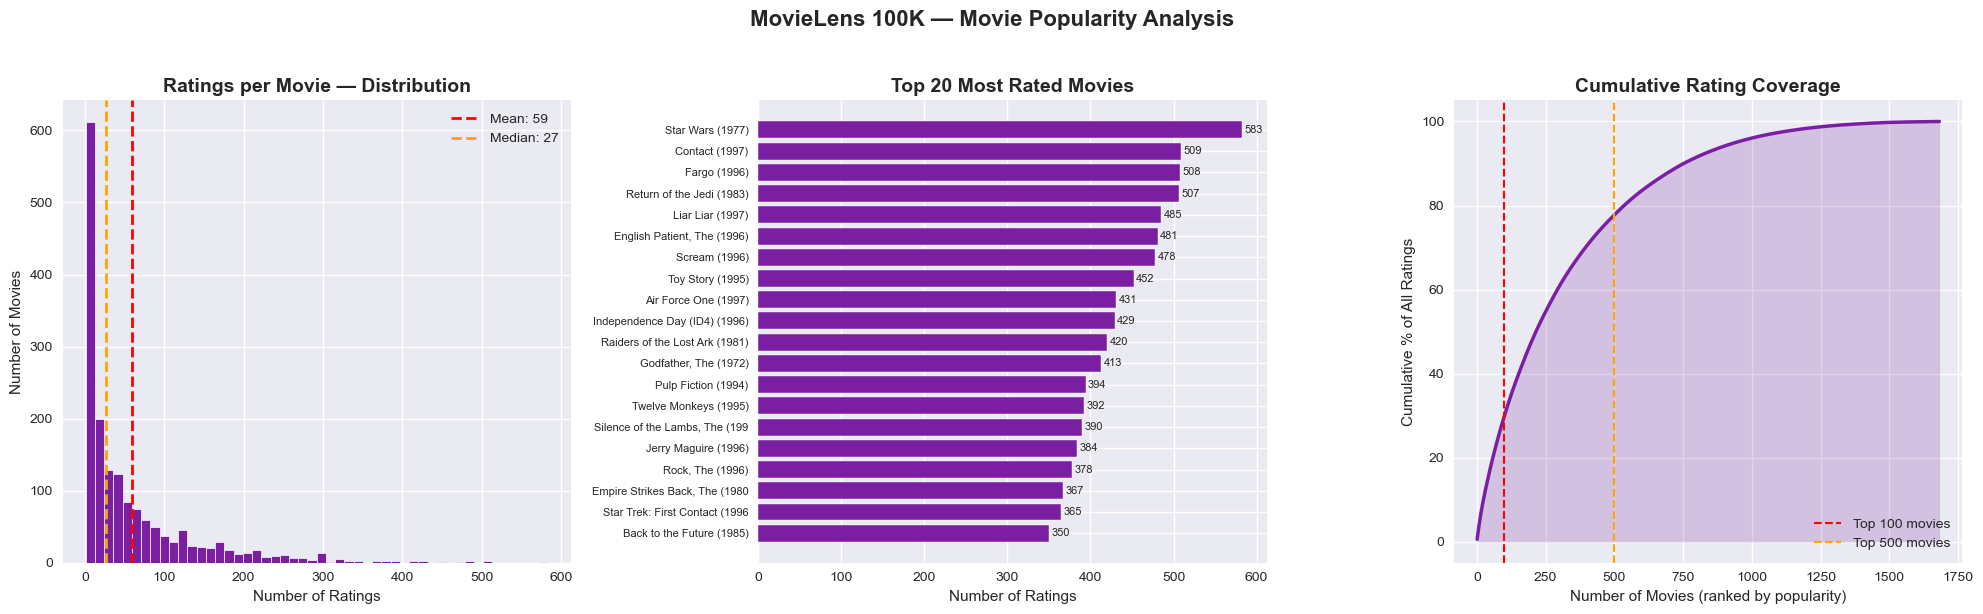


Movie Popularity Statistics:
Total movies           : 1,682
Mean ratings/movie     : 59.5
Median ratings/movie   : 27.0
Min ratings/movie      : 1
Max ratings/movie      : 583

Movies with < 10 ratings  : 530 (31.5%)
Movies with > 100 ratings : 334 (19.9%)

Top 10 most rated movies:
                        title  rating_count
             Star Wars (1977)           583
               Contact (1997)           509
                 Fargo (1996)           508
    Return of the Jedi (1983)           507
             Liar Liar (1997)           485
  English Patient, The (1996)           481
                Scream (1996)           478
             Toy Story (1995)           452
         Air Force One (1997)           431
Independence Day (ID4) (1996)           429


In [26]:
# Ratings per movie
ratings_per_movie = ratings.groupby('item_id')['user_id'].count()

# Merge with movie titles
movie_ratings = ratings_per_movie.reset_index()
movie_ratings.columns = ['item_id', 'rating_count']
movie_ratings = movie_ratings.merge(
    movies[['item_id', 'title']], on='item_id')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Chart 1 — Distribution of ratings per movie
axes[0].hist(ratings_per_movie.values, bins=50,
             color='#7b1fa2', edgecolor='white', linewidth=0.5)
axes[0].set_title('Ratings per Movie — Distribution',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Number of Movies')
axes[0].axvline(ratings_per_movie.mean(), color='red',
                linestyle='--', linewidth=2,
                label=f'Mean: {ratings_per_movie.mean():.0f}')
axes[0].axvline(ratings_per_movie.median(), color='orange',
                linestyle='--', linewidth=2,
                label=f'Median: {ratings_per_movie.median():.0f}')
axes[0].legend()

# Chart 2 — Top 20 most rated movies
top_movies = movie_ratings.nlargest(20, 'rating_count')
axes[1].barh(range(20), top_movies['rating_count'].values,
             color='#7b1fa2', edgecolor='white')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([t[:30] for t in top_movies['title'].values],
                         fontsize=8)
axes[1].set_title('Top 20 Most Rated Movies',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Ratings')
axes[1].invert_yaxis()
for i, val in enumerate(top_movies['rating_count'].values):
    axes[1].text(val + 3, i, str(val), va='center', fontsize=8)

# Chart 3 — Cumulative coverage
sorted_movies = movie_ratings.sort_values(
    'rating_count', ascending=False)
cumulative_ratings = sorted_movies['rating_count'].cumsum()
cumulative_pct = cumulative_ratings / cumulative_ratings.max() * 100
axes[2].plot(range(1, len(cumulative_pct) + 1),
             cumulative_pct.values,
             color='#7b1fa2', linewidth=2.5)
axes[2].fill_between(range(1, len(cumulative_pct) + 1),
                     cumulative_pct.values,
                     alpha=0.2, color='#7b1fa2')
axes[2].axvline(100, color='red', linestyle='--',
                linewidth=1.5, label='Top 100 movies')
axes[2].axvline(500, color='orange', linestyle='--',
                linewidth=1.5, label='Top 500 movies')
axes[2].set_title('Cumulative Rating Coverage',
                  fontsize=14, fontweight='bold')
axes[2].set_xlabel('Number of Movies (ranked by popularity)')
axes[2].set_ylabel('Cumulative % of All Ratings')
axes[2].legend()

plt.suptitle('MovieLens 100K — Movie Popularity Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/section5_movie_popularity.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMovie Popularity Statistics:")
print(f"Total movies           : {ratings_per_movie.count():,}")
print(f"Mean ratings/movie     : {ratings_per_movie.mean():.1f}")
print(f"Median ratings/movie   : {ratings_per_movie.median():.1f}")
print(f"Min ratings/movie      : {ratings_per_movie.min()}")
print(f"Max ratings/movie      : {ratings_per_movie.max()}")
print(f"\nMovies with < 10 ratings  : {(ratings_per_movie < 10).sum():,} ({(ratings_per_movie < 10).mean()*100:.1f}%)")
print(f"Movies with > 100 ratings : {(ratings_per_movie > 100).sum():,} ({(ratings_per_movie > 100).mean()*100:.1f}%)")
print(f"\nTop 10 most rated movies:")
print(movie_ratings.nlargest(10, 'rating_count')[['title', 'rating_count']].to_string(index=False))

**Section 5 Findings:**
- ✅ 1,682 total movies with severely skewed popularity distribution
- Mean 59.5 ratings/movie vs Median 27.0 — extreme right skew
- Star Wars (1977) dominates with 583 ratings — most rated film
- 31.5% of movies have fewer than 10 ratings — long tail confirmed
- Only 19.9% of movies have more than 100 ratings — reliable recommendation pool
- Top 100 movies cover ~40% of all ratings — severe concentration
- Top 500 movies cover ~75% of all ratings
- Long tail problem significant — SVD confidence drops sharply for obscure films
- Cold start problem for new movies — content-based filtering needed alongside CF

---
## Section 6 — Genre Analysis

Understand which genres dominate the dataset,
genre combinations, and implications for recommendations.

In [ ]:
# Define genre columns
genre_cols = ['unknown', 'Action', 'Adventure', 'Animation',
              'Children', 'Comedy', 'Crime', 'Documentary',
              'Drama', 'Fantasy', 'Film-Noir', 'Horror',
              'Musical', 'Mystery', 'Romance', 'Sci-Fi',
              'Thriller', 'War', 'Western']

# Count movies per genre